#### 환경 설정

In [2]:
import os

ROOT_DIR = os.getcwd()

# 코랩 모드
if ROOT_DIR == "/content":
    print("[[ colab ]]")
    
    import unicodedata
    
    DATA_DIR = os.path.join(ROOT_DIR, "raw")

    if "raw.tar.gz" not in os.listdir():
        !wget https://github.com/wonbywondev/ML-DL/releases/download/data-v3/raw.tar.gz
    else:
        print("· raw.tar.gz (O)")

    if not os.path.exists("/content/raw"):
        !tar -xzvf raw.tar.gz -C /content
    else:
        print("· data (O)")

    train_json_path = os.path.join(DATA_DIR, "일상생활및구어체_한영_train_set.json")
    val_json_path = os.path.join(DATA_DIR, "일상생활및구어체_한영_valid_set.json")

    train_json_path = unicodedata.normalize("NFC", train_json_path)
    val_json_path = unicodedata.normalize("NFC", val_json_path)

# 로컬 모드
else:
    print("[[ local ]]")
    
    DATA_DIR = os.path.join(ROOT_DIR, "data")

    train_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_train_set.json")
    val_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_valid_set.json")

[[ local ]]


In [3]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


Matplotlib is building the font cache; this may take a moment.


---

# 목표

번역기 만들기

In [4]:
import json

with open(train_json_path, "r", encoding="utf-8") as f:
    TRAIN_DATA = json.load(f)

TRAIN_DATA = TRAIN_DATA["data"]

### 샘플 출력

In [5]:
import random

rand_idx = random.randint(1, len(TRAIN_DATA)) - 1

TRAIN_DATA[rand_idx]

{'sn': 'INTSALMCHO062119042613449',
 'data_set': '일상생활및구어체',
 'domain': '해외영업',
 'subdomain': '기계장비,의료정밀',
 'ko_original': '선적으로 보내게 되면 시간이 오래 걸리지만 금액이 저렴하다고 이야기 드렸습니다.',
 'ko': '선적으로 보내게 되면 시간이 오래 걸리지만 금액이 저렴하다고 이야기 드렸습니다.',
 'mt': 'I told you that it takes a long time to send it by shipment, but the price is cheap.',
 'en': 'I told you that it takes a long time to send it by shipment, but the price is cheap.',
 'source_language': 'ko',
 'target_language': 'en',
 'word_count_ko': 10,
 'word_count_en': 19,
 'word_ratio': 1.9,
 'file_name': 'INTSAL_MCHO.xlsx',
 'source': '크라우드소싱',
 'license': 'open',
 'style': '구어체',
 'included_unknown_words': False,
 'ner': None}

ner은 Named Entity Recognition. 꼭 살려둬야 한다.

In [6]:
print("[데이터 속성 고유값]")

unique_dict = {key: (set() if key != "ner" else list()) for key in TRAIN_DATA[0].keys()}

for i, dict_ in enumerate(TRAIN_DATA):   
    for key, value in dict_.items():
        if key == "ner":
            unique_dict[key].append(value if value else "null")
        else:
            unique_dict[key].add(value if value else "null")


for key, value in unique_dict.items():
    print(f"· {key}: {len(value)}개")

    if len(value) < 20:
        print(f"    - {value}")

[데이터 속성 고유값]
· sn: 1200000개
· data_set: 1개
    - {'일상생활및구어체'}
· domain: 3개
    - {'해외고객과의채팅', '일상생활', '해외영업'}
· subdomain: 11개
    - {'부동산', '음식', '정보통신', '숙박,음식점', '예약', '기계장비,의료정밀', '연구개발,과학기술', '도소매유통', '금융,보험', '구매', '여행'}
· ko_original: 1059799개
· ko: 1059798개
· mt: 1015045개
· en: 1024329개
· source_language: 1개
    - {'ko'}
· target_language: 1개
    - {'en'}
· word_count_ko: 56개
· word_count_en: 73개
· word_ratio: 673개
· file_name: 18개
    - {'예약_KRSS.xlsx', 'INTSAL_MCHO.xlsx', 'INTSAL_JBTS.xlsx', '구매_KPUS.xlsx', 'INTSAL_RLST.xlsx', 'CUSCHA_STRS.xlsx', '여행_KTOS.xlsx', 'INTSAL_DSUT.xlsx', 'INTSAL_EGKG.xlsx', 'CUSCHA_JBTS.xlsx', '음식_KFDS.xlsx', 'CUSCHA_FNIN.xlsx', 'INTSAL_FNIN.xlsx', 'CUSCHA_EGKG.xlsx', 'INTSAL_STRS.xlsx', 'CUSCHA_DSUT.xlsx', 'CUSCHA_MCHO.xlsx', 'CUSCHA_RLST.xlsx'}
· source: 2개
    - {'SBS', '크라우드소싱'}
· license: 1개
    - {'open'}
· style: 1개
    - {'구어체'}
· included_unknown_words: 1개
    - {'null'}
· ner: 1200000개


### 중복치

domain, subdomain, 내용이 일치하는 데이터를 언어별로 삭제.

번역본끼리 한 쌍, 원본끼리 한 쌍으로 묶는다.

In [7]:
import pandas as pd

useless_list = [
    "sn", "data_set", "license", "source", "style", 
    "included_unknown_words", "file_name", 
    "source_language", "target_language"
    ]

useful_list = [column for column in list(TRAIN_DATA[0].keys()) if column not in useless_list]

train_df = pd.DataFrame(TRAIN_DATA, columns=useful_list)

In [8]:
lang_list = [["ko_original", "en"], ["ko", "mt"]]

for lang in lang_list:
    train_df = train_df.drop_duplicates(["domain", "subdomain"] + lang, keep="first")

print(f"· 중복 제거 후 데이터: {len(train_df)}개")

· 중복 제거 후 데이터: 1080887개


### 극단치

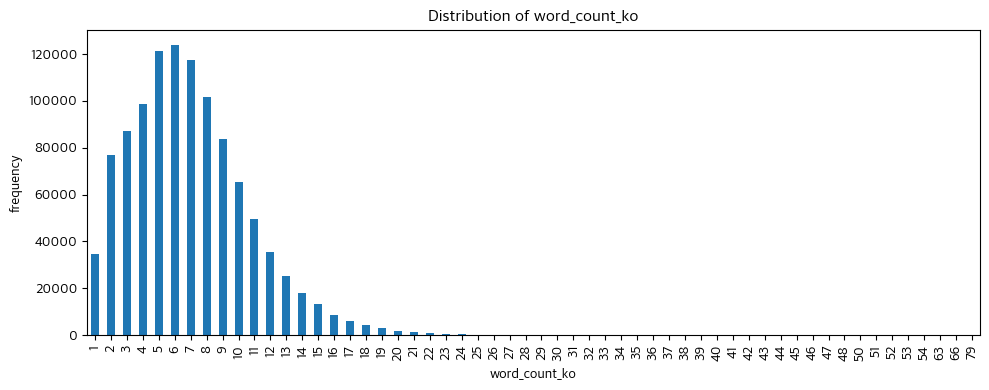

In [9]:
# word_count_ko
counts = train_df["word_count_ko"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_ko")
plt.ylabel("frequency")
plt.title("Distribution of word_count_ko")
plt.tight_layout()
plt.show()

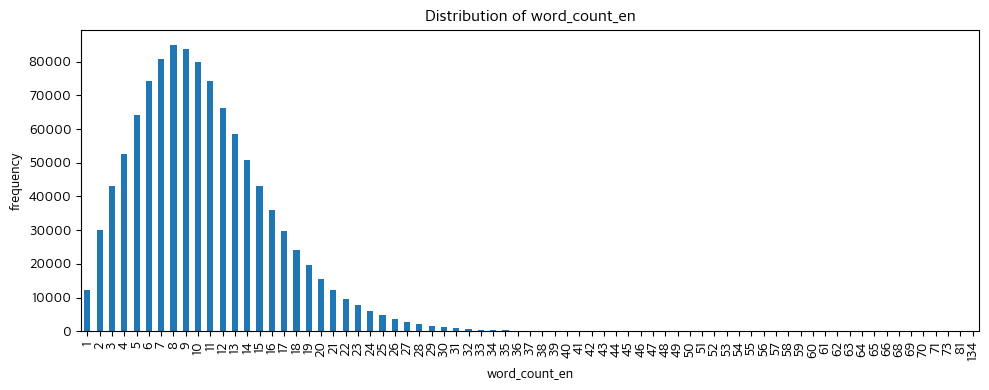

In [10]:
# word_count_en
counts = train_df["word_count_en"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_en")
plt.ylabel("frequency")
plt.title("Distribution of word_count_en")
plt.tight_layout()
plt.show()

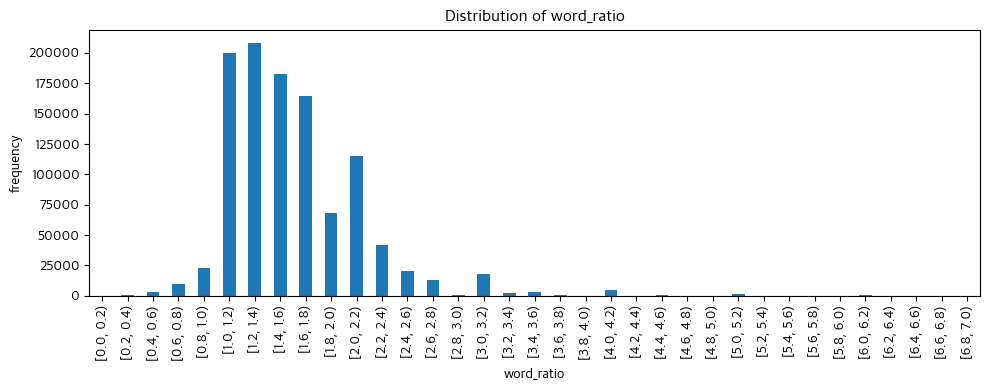

In [11]:
# word_ratio
import numpy as np

bins = np.arange(0, 7.2, 0.2)
groups = pd.cut(train_df["word_ratio"], bins=bins, right=False)

counts = groups.value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_ratio")
plt.ylabel("frequency")
plt.title("Distribution of word_ratio")
plt.tight_layout()

plt.show()

In [12]:
train_df = train_df[train_df["word_count_ko"] <= 25]
train_df = train_df[train_df["word_count_en"] <= 35]
train_df = train_df[train_df["word_ratio"] <= 3.5]

### 도메인 맵핑

In [13]:
DOMAIN_KEY_MAP = {value: i for i, value in enumerate(unique_dict["domain"])}
SUBDOMAIN_KEY_MAP = {value: i for i, value in enumerate(unique_dict["subdomain"])}

DOMAIN_NUM_MAP = {i:value for i, value in enumerate(unique_dict["domain"])}
SUBDOMAIN_NUM_MAP = {i:value for i, value in enumerate(unique_dict["subdomain"])}

train_df["domain"] = train_df['domain'].map(DOMAIN_KEY_MAP)
train_df["subdomain"] = train_df['subdomain'].map(SUBDOMAIN_KEY_MAP)

In [14]:
train_df = train_df.reset_index().drop("index", axis=1)

In [15]:
TRAIN_DICT = train_df.to_dict("index")
print(f"· 가공 후 데이터: {len(TRAIN_DICT)}개")

· 가공 후 데이터: 1070866개


In [16]:
rand_idx = random.randint(1, len(TRAIN_DICT)) - 1

print("[가공 후 샘플 출력]")
print(f"key: {rand_idx}")
TRAIN_DICT[rand_idx]

[가공 후 샘플 출력]
key: 729501


{'domain': 2,
 'subdomain': 7,
 'ko_original': '화이트 세라믹 머그 4종 세트인 이 머그잔 세트는 매력적으로 페인트칠된 소나무와 반짝이는 금속 별이 특징으로 친구와 저녁 티타임에 적합합니다.',
 'ko': '화이트 세라믹 머그 4종 세트인 이 머그잔 세트는 매력적으로 페인트칠된 소나무와 반짝이는 금속 별이 특징으로 친구와 저녁 티타임에 적합합니다.',
 'mt': 'This four-piece set of white ceramic mugs features charmingly painted pine trees and twinkling metallic stars, perfect for an evening tea time with friends.',
 'en': 'This four-piece set of white ceramic mugs features charmingly painted pine trees and twinkling metallic stars, perfect for an evening tea time with friends.',
 'word_count_ko': 19,
 'word_count_en': 24,
 'word_ratio': 1.263,
 'ner': None}

# 실험 계획

1. ner 데이터를 이용하여 다른 데이터에도 적용한다.

In [22]:
ner_dict = dict()

for key, value in TRAIN_DICT.items():
    if value["ner"]:
        ner_dict[key] = value["ner"]

In [32]:
unique_ner_tag_set = set()

for key, value in ner_dict.items():
    for tag_dict in value["tags"]:
        if tag_dict["tag"] not in value["text"]:
            print("error key:", key)
            print(tag_dict)
            print(value["text"], "\n")
        unique_ner_tag_set.add(tag_dict["tag"])


error key: 126016
{'tag': 'PRODUCT', 'value': '아마존 알렉사', 'position': '[9, 16]'}
<ORG>구글</ORG> 어시스턴트 아마존 알렉사를 통해 제어할 수 있다. 

error key: 126016
{'tag': 'PRODUCT', 'value': '구글 어시스턴트', 'position': '[0, 8]'}
<ORG>구글</ORG> 어시스턴트 아마존 알렉사를 통해 제어할 수 있다. 

error key: 435082
{'tag': 'WORK_OF_ART', 'value': '픽사 토이스토리', 'position': '[30, 38]'}
3~8세 어린이용이 소장용 피규어로 아이들은 BBB·픽사 토이스토리 영화에서 좋아하는 순간을 재현하고 자신만의 새로운 순간을 만들 수 있습니다. 

error key: 435082
{'tag': 'WORK_OF_ART', 'value': 'BBB', 'position': '[26, 29]'}
3~8세 어린이용이 소장용 피규어로 아이들은 BBB·픽사 토이스토리 영화에서 좋아하는 순간을 재현하고 자신만의 새로운 순간을 만들 수 있습니다. 

error key: 474648
{'tag': 'WORK_OF_ART', 'value': '백종원의 골목식당', 'position': '[1, 10]'}
><PERSON>백종원</PERSON>의 골목식당 충청남도 서산에 있는 해미읍성이라는 곳입니다. 

error key: 520783
{'tag': 'PERSON', 'value': '박', 'position': '[17, 18]'}
옆에 계신 분은 제 상사이신 박 이사님이십니다 

error key: 650740
{'tag': 'PERSON', 'value': '박', 'position': '[17, 18]'}
옆에 계신 분은 제 상사이신 박이사님 이십니다 

error key: 711506
{'tag': 'ORG', 'value': 'QC', 'position': '[45, 47]'}
모

In [27]:
unique_ner_tag_set

{'ORG', 'PERSON', 'PRODUCT', 'WORK_OF_ART'}

In [ ]:
ner_dict

{25: {'text': '>와우<PERSON>영미</PERSON>.',
  'tags': [{'tag': 'PERSON', 'value': '영미', 'position': '[3, 5]'}]},
 39: {'text': '>야, <PERSON>석진이</PERSON> 형 뒤에 안 했다.',
  'tags': [{'tag': 'PERSON', 'value': '석진이', 'position': '[4, 7]'}]},
 163: {'text': '<PERSON>일라이</PERSON>: <PRODUCT>니모</PRODUCT>는 얼마나 깊이 들어갈 수 있고 배터리 팩은 얼마나 오래 지속되나요?',
  'tags': [{'tag': 'PRODUCT', 'value': '니모', 'position': '[5, 7]'},
   {'tag': 'PERSON', 'value': '일라이', 'position': '[0, 3]'}]},
 178: {'text': '혹시 그냥 <PRODUCT>엑셀</PRODUCT> 파일로 저희에게 보내주실수 있을까요?',
  'tags': [{'tag': 'PRODUCT', 'value': '엑셀', 'position': '[6, 8]'}]},
 220: {'text': '> <ORG>SM</ORG>이나 이런 덴 없어요.',
  'tags': [{'tag': 'ORG', 'value': 'SM', 'position': '[2, 4]'}]},
 246: {'text': '그리고 아이들은 페이지 분량의 <PRODUCT>스프링노트 스타일 액티비티 패드</PRODUCT>에서 <WORK_OF_ART>겨울왕국</WORK_OF_ART> 라인 아트를 색칠하고 꾸미는 재미에 빠져볼 것입니다.',
  'tags': [{'tag': 'WORK_OF_ART', 'value': '겨울왕국', 'position': '[37, 41]'},
   {'tag': 'PRODUCT', 'value': '스프링노트 스타일 액티비티 패드', 'position': '[17, 34]'}]

In [24]:
for key, value in ner_dict.items():
    print(value)
    break

{'text': '>와우<PERSON>영미</PERSON>.', 'tags': [{'tag': 'PERSON', 'value': '영미', 'position': '[3, 5]'}]}
